  <div class="alert alert-info">
  Привет, Дмитрий! Меня зовут Светлана Чих и я буду проверять твой проект. Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе. Предлагаю общаться на «ты». Но если это не удобно - дай знать, и мы перейдем на «вы».

  <div class="alert alert-success">
  <b>👍 Успех:</b> Зелёным цветом отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах.
  </div>
  <div class="alert alert-warning">
  <b>🤔 Рекомендация:</b> Жёлтым цветом выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).
  </div>
  <div class="alert alert-danger">
  <b>😔 Необходимо исправить:</b> Красным цветом выделены комментарии, без исправления которых, я не смогу принять проект :(
  </div>
  <div class="alert alert-info">
  <b>👂 Совет:</b> Какие-то дополнительные материалы
  </div>
  Давай работать над проектом в диалоге: если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом.
  Мне будет легче отследить изменения, если ты выделишь свои комментарии:
  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Например, вот так.</div>
  Пожалуйста, не перемещай, не изменяй и не удаляй мои комментарии. Всё это поможет выполнить повторную проверку твоего проекта быстрее.
   </div>

  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Добрый день! Прошу Вас посмотреть предварительно, все ли в целом так.
   </div>

# Описание проекта

**Задача: нужно создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения.**

 Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.

Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Чёткого алгоритма работы и подобных решений на рынке ещё не существует. Текущая задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

Идея решения задачи от заказчика: 
- Создать модель предсказания ДТП (целевое значение — at_fault (виновник) в таблице parties)
- Для модели выбрать тип виновника — только машина (car).
- Выбрать случаи, когда ДТП привело к любым повреждениям транспортного средства, кроме типа SCRATCH (царапина).
- Для моделирования ограничиться данными за 2012 год — они самые свежие.
- **Обязательное условие — учесть фактор возраста автомобиля.** (хотя, там 74% пропусков - шум для модели)
- На основе модели исследовать основные факторы ДТП.
- Понять, помогут ли результаты моделирования и анализ важности факторов ответить на вопросы:
- - Возможно ли создать адекватную системы оценки водительского риска при выдаче авто?
- - Какие ещё факторы нужно учесть?
- - Нужно ли оборудовать автомобиль какими-либо датчиками или камерой?
Заказчик предлагает вам поработать с базой данных по происшествиям и сформировать свои идеи создания такой системы. 

# 0. Настройка рабочего пространства

In [1]:
# !pip install catboost

In [2]:
import numpy as np
import pandas as pd
import psycopg2

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix


from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import joblib

import warnings
warnings.filterwarnings('ignore')


c:\Users\dmi-a\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


<div class="alert alert-danger">
<b>😔 Необходимо исправить:</b> Все импорты должны быть в начале работы, здесь явно не все нужные. И запуск проекта долден быть с 1 ячейки, при перезапуске нужно перезапускать ядро
</div>


# **1. Загрузка таблицы sql**
Подключение к базе данных, используя данные:

In [3]:
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-science-vehicle-db'
}

connection_string = f"host={db_config['host']} port={db_config['port']} dbname={db_config['db']} user={db_config['user']} password={db_config['pwd']} sslmode=require"

def run_query(sql_query):
    """Выполняет SQL-запрос и возвращает результат в виде DataFrame."""
    with psycopg2.connect(connection_string) as conn:
        df = pd.read_sql(sql_query, conn)
    return df

<div class="alert alert-success">
<b>👍 Успех:</b> Создано подключение к БД!
</div>

In [4]:
# # Сохранение результатов SQL запросов в csv файлы

# collisions = run_query("SELECT * FROM collisions")
# parties = run_query("SELECT * FROM parties")
# vehicles = run_query("SELECT * FROM vehicles")

# collisions.to_csv('collisions.csv', index=False)
# print(f"Сохранено: collisions {collisions.shape}")

# parties.to_csv('parties.csv', index=False)
# print(f"Сохранено: parties {parties.shape}")

# vehicles.to_csv('vehicles.csv', index=False)
# print(f"Сохранено: vehicles {vehicles.shape}")


# **1.2. Описание таблиц базы данных**

### **1.2.1. collisions (информация о происшествиях, общая информация о ДТП)**

Имеет уникальный case_id. Эта таблица описывает общую информацию о ДТП. Например, где оно произошло и когда.

| Описание | Обозначение в таблице | Подробнее |
|----------|----------------------|-----------|
| Идентификационный номер в базе данных | CASE_ID | Уникальный номер для зарегистрированного происшествия в таблице происшествий |
| Дата происшествия | COLLISION_DATE | Формат год/месяц/день |
| Время происшествия | COLLISION_TIME | Формат: 24-часовой |
| Является ли место происшествия перекрёстком | INTERSECTION | Intersection (перекрёсток)<br>Not Intersection (не перекрёсток)<br>Not stated (Не указано) |
| Погода | WEATHER_1 | Clear <br>Cloudy<br>Raining<br>Snowing<br>Fog<br>Other<br>Wind <br>Not Stated |
| Серьёзность происшествия | COLLISION_DAMAGE | FATAL ТС <br>SEVERE DAMAGE <br>MIDDLE DAMAGE <br>SMALL DAMAGE <br>SCRATCH (Царапина) |
| Основной фактор аварии | PRIMARY_COLLISION_FACTOR |Code Violation (Нарушение ПДД)<br>Other Improper Driving<br>Other Than Driver<br>Unknown<br>Fell Asleep<br>Not Stated |
| Состояние дороги | ROAD_SURFACE | Dry<br>Wet<br>Snowy or Icy<br>Slippery<br>Not Stated |
| Освещение | LIGHTING | Daylight<br> Dusk-Dawn<br>Dark-Street Lights<br>Dark-No Street Lights<br>Dark-Street Lights Not Functioning<br>- — Not Stated |
| Номер географических районов | COUNTY_CITY_LOCATION | число |
| Названия географических районов | COUNTY_LOCATION | категориальный тип данных |
| Направление движения | DIRECTION |North<br>East<br>South<br>West<br>- — Not State |
| Расстояние от главной дороги (метры) | DISTANCE | число |
| Тип дороги | LOCATION_TYPE |Highway<br>Intersection<br>Ramp<br>Not State |
| Количество участников | PARTY_COUNT | число |
| Категория нарушения | PCF_VIOLATION_CATEGORY |DUI<br>Impeding Traffic<br>Unsafe Speed<br>Following Too Closely<br>Wrong Side of Road<br>Improper Passing<br>Unsafe Lane Change<br>Improper Turning<br>Automobile Right of Way<br>Pedestrian Right of Way<br>Pedestrian Violation<br>Traffic Signals and Signs<br>Hazardous Parking<br>Lights<br>Brakes<br>Other Equipment<br>Other Hazardous Violation<br>Other Than Driver<br>Speeding<br>Pedestrian dui<br>Unsafe Starting or Backing<br>Other Improper Driving<br>Pedestrian Under Influence<br>Fell Asleep<br>Unknown<br>Not Stated |
| Тип аварии | TYPE_OF_COLLISION | Head-On<br>Sideswipe<br>Rear End<br>Broadside<br>Hit Object<br>Overturned<br>Vehicle/Pedestrian<br>Other<br>Not Stated |
| Дополнительные участники ДТП | MOTOR_VEHICLE_INVOLVED_WITH | Other motor vehicle<br>Fixed object<br>Parked motor vehicle<br>Pedestrian<br>Bicycle<br>Non-collision<br>Other object<br>Motor vehicle on other roadway<br>Animal<br>Train |
| Дорожное состояние | ROAD_CONDITION_1 | Holes, Deep Ruts<br>Loose Material<br>Obstruction<br>Construction Zone<br>Reduced Width<br> Flooded<br>Other<br>No Unusual Condition<br>Not Stated |

### **1.2.2. Parties (описание участников происшествия)**

 информация об участниках ДТП

Имеет неуникальный case_id, который сопоставляется с соответствующим ДТП в таблице collisions. Каждая строка здесь описывает одну из сторон, участвующих в ДТП. Если столкнулись две машины, в этой таблице должно быть две строки с совпадением case_id. Если нужен уникальный идентификатор, это case_id and party_number.

| Описание | Обозначение в таблице | Подробнее |
|---|---|---|
| Идентификационный номер в базе данных | CASE_ID | Уникальный номер для зарегистрированного происшествия в таблице происшествий. |
| Номер участника происшествия | PARTY_NUMBER | От 1 до N — по числу участников происшествия |
| Тип участника происшествия | PARTY_TYPE | Car <br> Road bumper <br> Building <br> Road signs <br> Other <br> Operator <br> Not Stated |
| Виновность участника | AT_FAULT | 0/1 |
| Сумма страховки (тыс. $) | INSURANCE_PREMIUM | число |
| Состояние участника: физическое или с учётом принятых лекарств | PARTY_DRUG_PHYSICAL | Under Drug Influence (Под воздействием лекарств) <br> Impairment — Physical (Ухудшение состояния) <br> Impairment Unknown (Не известно) <br> Not Applicable (Не оценивался) <br> Sleepy/Fatigued (Сонный/Усталый) <br> Not Stated (Не указано) |
| Трезвость участника | PARTY_SOBRIETY | Had Not Been Drinking (Не пил) <br> Had Been Drinking, Under Influence (Был пьян, под влиянием) <br> Had Been Drinking, Not Under Influence (Был пьян, не под влиянием) <br> Had Been Drinking, Impairment Unknown (Был пьян, ухудшение неизвестно) <br> Impairment Unknown (Неизвестно ухудшение) <br> Not Applicable (Не оценивался) <br> Not Stated (Не указано) |
| Наличие телефона в автомобиле (возможности разговаривать по громкой связи) | CELLPHONE_IN_USE | 0/1 |

### **1.2.3. Vehicles (Описание автомобиля, информация о пострадавших машинах)**

Имеет неуникальные case_id и неуникальные party_number, которые сопоставляются с таблицей collisions и таблицей parties. Если нужен уникальный идентификатор, это case_id and party_number.

| **Описание** | **Обозначение в таблице** | **Подробнее** |
|---|---|---|
| Индекс текущей таблицы | ID | Номер в таблице |
| Идентификационный номер в базе данных | CASE_ID | Уникальный номер для зарегистрированного происшествия в таблице происшествий. |
| Номер участника происшествия | PARTY_NUMBER | От 1 до N — по числу участников происшествия |
| Тип кузова | VEHICLE_TYPE | MINIVAN <br> COUPE <br> SEDAN <br> HATCHBACK <br> OTHER |
| Тип КПП | VEHICLE_TRANSMISSION | auto (Автоматическая) <br> manual (Ручная) <br> - — Not Stated (Не указано) |
| Возраст автомобиля (в годах) | VEHICLE_AGE | число |

# **2. Первичное исследование таблиц**

- Все ли таблицы имеют набор данныхи и соответствует ли количество таблиц условию задачи;
- Имеется ли общий ключ для связи таблиц.

Для осмотра таблиц используем обернутый sql-запрос.

## **2.1. Все ли таблицы имеют набор данных**

In [5]:
# 1. Проверяем количество записей в каждой таблице

count_query = """
                SELECT 
                    (SELECT COUNT(*) FROM collisions) AS collisions_count,
                    (SELECT COUNT(*) FROM parties) AS parties_count,
                    (SELECT COUNT(*) FROM vehicles) AS vehicles_count;
                    
                """
                
counts_df = run_query(count_query)
print("Количество записей в таблицах:")
print(counts_df)

Количество записей в таблицах:
   collisions_count  parties_count  vehicles_count
0           1400000        2752408         1021234


In [6]:
date_query = """
            SELECT 
                DATE_TRUNC('month', collision_date) AS month_year,
                COUNT(*) AS total_collisions
            FROM collisions
            WHERE EXTRACT(YEAR FROM collision_date) BETWEEN 2009 AND 2011
            GROUP BY DATE_TRUNC('month', collision_date)
            ORDER BY month_year;
            """

crash_dates_df = run_query(date_query)
display(crash_dates_df)

,month_year,total_collisions
0,2009-01-01 00:00:00+03:00,35062
1,2009-02-01 00:00:00+03:00,34480
2,2009-03-01 00:00:00+03:00,36648
3,2009-04-01 00:00:00+04:00,35239
4,2009-05-01 00:00:00+04:00,36916
5,2009-06-01 00:00:00+04:00,34202
6,2009-07-01 00:00:00+04:00,35161
7,2009-08-01 00:00:00+04:00,34508
8,2009-09-01 00:00:00+04:00,35555
9,2009-10-01 00:00:00+04:00,37835


In [7]:
crash_dates_df['month_year'] = pd.to_datetime(crash_dates_df['month_year'], utc=True).dt.to_period('M').astype(str)

# 1. Преобразуем столбец в datetime с часовым поясом
crash_dates_df['month_year_dt'] = pd.to_datetime(crash_dates_df['month_year'], utc=True)

# 2. Создаём отдельные колонки для Года и Месяца
crash_dates_df['year'] = crash_dates_df['month_year_dt'].dt.year
crash_dates_df['month'] = crash_dates_df['month_year_dt'].dt.month

# 3. Создаем сводную таблицу с помощью pivot_table
pivot_result = crash_dates_df.pivot_table(
    values='total_collisions',      # Значение, которое будем агрегировать
    index='month',                  # Строки - месяцы (1-12)
    columns='year',                 # Столбцы - годы
    aggfunc='sum',                  # Функция агрегации (сумма)
    margins=True,                   # Добавить итоговую строку (All)
    margins_name='Итого за месяц'   # Название итоговой строки
)

# 4. Для красоты можно переименовать числовые индексы месяцев в названия
# Создадим словарь для замены
month_names = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
    5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
    9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}
pivot_result.index = pivot_result.index.map(month_names)

# 5. Отобразим результат (в Jupyter Notebook) или выведем в консоль
pivot_result

year,2008,2009,2010,2011,Итого за месяц
month,,,,,
Январь,NaN,34480.0,31918.0,31975.0,98373
Февраль,NaN,36648.0,35803.0,34585.0,107036
Март,NaN,35239.0,34416.0,31377.0,101032
Апрель,NaN,36916.0,34862.0,33370.0,105148
Май,NaN,34202.0,33367.0,31962.0,99531
Июнь,NaN,35161.0,33645.0,33029.0,101835
Июль,NaN,34508.0,34620.0,34339.0,103467
Август,NaN,35555.0,34957.0,34137.0,104649
Сентябрь,NaN,37835.0,37480.0,36618.0,111933


**Промежуточный вывод:**
- до 2009 года данные неполные
- с 2012 года данные стало сильно меньше - данные неполные
- с 14 по 19 год данных нет.

Для анализа и обучения модели оставим только полные данные с 2009 по 2011 год.

Необходимо ограничить выборку периодом 2009-2011.

## **2.2. Имеются ли общие ключи**

In [8]:
# 2. Проверяем наличие общих ключей для связи таблиц
# Связь collisions <-> parties по CASE_ID
# Связь parties <-> vehicles по CASE_ID и PARTY_NUMBER
keys_query = """

WITH stats AS (
    -- Проверка 1: Есть ли связь между Collisions и Parties?
    -- Мы ищем, что для КАЖДОГО происшествия есть участник.
    -- Если запрос EXISTS возвращает TRUE, значит связь есть.
    SELECT 
        'collisions_with_parties' AS metric,
        CASE 
            -- Проверяем, что НЕТ ни одного происшествия без участника
            WHEN NOT EXISTS (
                SELECT 1
                FROM collisions c
                LEFT JOIN parties p ON c.CASE_ID = p.CASE_ID
                WHERE p.CASE_ID IS NULL -- Ключевое условие: участника не нашли
            ) THEN 'TRUE' ELSE 'FALSE' 
        END AS status

    UNION ALL

    -- Проверка 2: Есть ли связь между Parties (авто) и Vehicles?
    -- Мы ищем, что для КАЖДОГО участника-автомобилиста есть запись о машине.
    SELECT 
        'car_parties_with_vehicles' AS metric,
        CASE 
            -- Проверяем, что НЕТ ни одного автомобилиста без машины
            WHEN NOT EXISTS (
                SELECT 1
                FROM parties p
                LEFT JOIN vehicles v 
                    ON p.CASE_ID = v.CASE_ID AND p.PARTY_NUMBER = v.PARTY_NUMBER
                WHERE p.PARTY_TYPE = '1' -- Только машины
                  AND v.CASE_ID IS NULL -- Ключевое условие: машину не нашли
            ) THEN 'TRUE' ELSE 'FALSE'
        END AS status
)
SELECT * FROM stats;

            """

print("Проверяем наличие общих ключей для связи таблиц...")
display(run_query(keys_query))

Проверяем наличие общих ключей для связи таблиц...


,metric,status
0,collisions_with_parties,TRUE
1,car_parties_with_vehicles,TRUE


Это означает: «Связь найдена, данные целостны, можно работать», и полностью готовы для анализа. 

Общие ключи есть в трех таблицах.

Связи между всеми тремя таблицами работают корректно, каждое ДТП в базе кем-то зарегистрировано. Нет записей о происшествиях без участников.

## **3. Структура таблиц**

In [9]:
# 3. Структура таблиц (первые строки и описание колонок)
print("\nСтруктура таблицы collisions:")
display(run_query("SELECT * FROM collisions LIMIT 5"))

print("\nСтруктура таблицы parties:")
display(run_query("SELECT * FROM parties LIMIT 5"))

print("\nСтруктура таблицы vehicles:")
display(run_query("SELECT * FROM vehicles LIMIT 5"))


Структура таблицы collisions:


,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,None,1,clear,None,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,None,1,clear,None,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,None,1,clear,None,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,None,dark with street lights,functioning,2009-01-02,22:43:00



Структура таблицы parties:


,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,None,0
1,23,3899454,2,road signs,0,7.0,had not been drinking,None,0
2,29,3899462,2,car,0,21.0,had not been drinking,None,0
3,31,3899465,2,road signs,0,24.0,had not been drinking,None,0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0



Структура таблицы vehicles:


,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5


<div class="alert alert-success">
<b>👍 Успех:</b> Таблицы просмотрены!
</div>

# **3. Статистический анализ факторов ДТП**

## **3.1. Анализ количества аварий по месяцам за 2009-2011**

Для понимания сезонности и общей динамики необходимо выяснить, в какие месяцы происходит наибольшее количество аварий. Проанализировать весь период наблюдений.

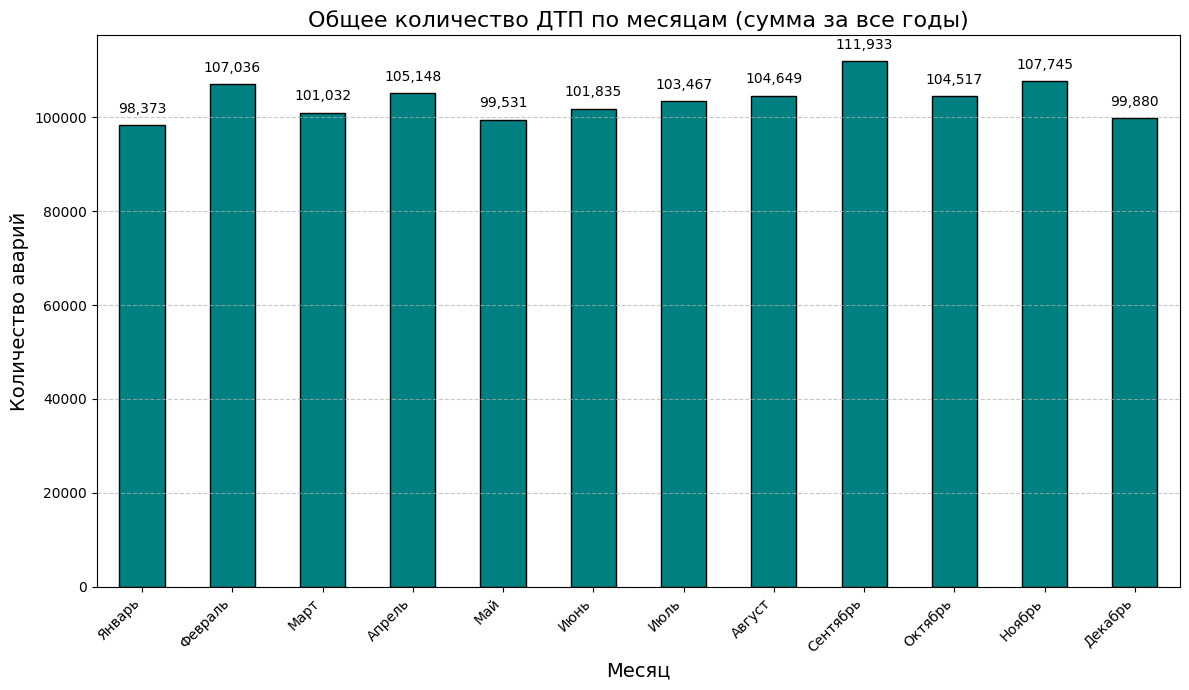

In [10]:
# 1. Получаем последний столбец (результаты по месяцам)
monthly_total = pivot_result.iloc[:, -1]

# 2. Удаляем последнее значение (общий итог) из серии
monthly_total = monthly_total[:-1]  # [-1:] означает удаление последнего элемента

# 3. Строим столбчатую диаграмму
monthly_total.plot.bar(color='teal', edgecolor='black', figsize=(12, 7))

# 4. Настройка графиков
plt.title('Общее количество ДТП по месяцам (сумма за все годы)', fontsize=16)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('Количество аварий', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Подписываем значения над столбиками
for i, v in enumerate(monthly_total.values):
    plt.text(i, v + 2000, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Взаимосвязи и определнной тенденции выявить не удалось.

## **3.2.1. Задача №1:** Анализ серьёзности повреждений в зависимости от состояния дороги
**Цель:** Проверить гипотезу о том, что мокрые и обледенелые дороги приводят к более серьезным повреждениям ТС.



In [11]:
query = """
SELECT
    c.ROAD_SURFACE,
    c.COLLISION_DAMAGE,
    COUNT(*) as accident_count
FROM collisions c
LEFT JOIN parties p 
    ON c.CASE_ID = p.CASE_ID 
    AND p.PARTY_TYPE = 'car'
WHERE 
    c.COLLISION_DAMAGE != 'scratch'
    AND (p.PARTY_TYPE = 'car' OR p.PARTY_TYPE IS NULL) 
    AND EXTRACT(YEAR FROM c.collision_date) BETWEEN 2009 AND 2011
GROUP BY c.ROAD_SURFACE, c.COLLISION_DAMAGE
ORDER BY 1, 3 DESC;
"""

damage_df = run_query(query)

display(damage_df)

,road_surface,collision_damage,accident_count
0,dry,small damage,1172514
1,dry,middle damage,213821
2,dry,severe damage,36641
3,dry,fatal,10655
4,slippery,small damage,984
5,slippery,middle damage,284
6,slippery,severe damage,71
7,slippery,fatal,11
8,snowy,small damage,6042
9,snowy,middle damage,891


<div class="alert alert-danger">
<b>😔 Необходимо исправить:</b> Что за условие p.PARTY_TYPE = '1' и почему оно перенесно в JOIN? И почему COLLISION_DAMAGE != '0'? Откуда такие значения? Ты же можешь посмотреть какие значения есть в этих признаках. В ячейке выше ты выводишь collision_damage, там есть цифры? 
</div>

  <div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Потому что этот жуткий непонятный sql, было бы гораздо проще и лдегче делать все в питоне

  Спасибо что обратили мое внимание на это/

  Зачем сделано такое странное описание данных, котолрое запутывает? и так ничего не понятно??? можно же было при описании данных напистаь по-человечески без цифр (1 - car).. а просто реальные значения (car)... для чего специально запутывать и добавлять бдуквенные и цифровые обозначения..

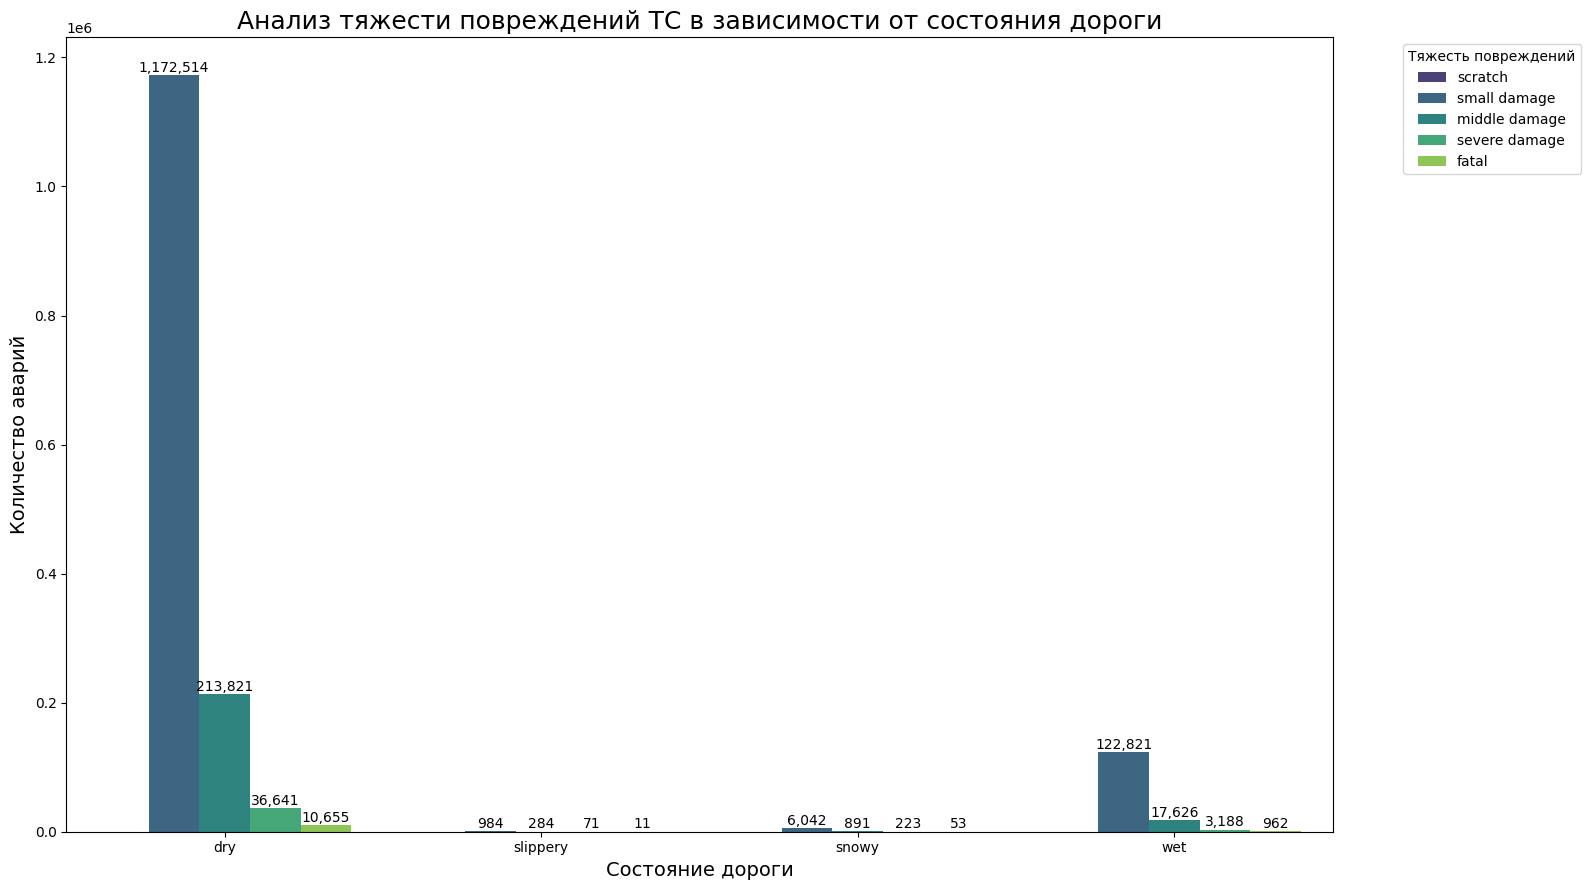

In [12]:
damage_order = ['scratch', 'small damage', 'middle damage', 'severe damage', 'fatal']
damage_df['collision_damage'] = pd.Categorical(damage_df['collision_damage'], categories=damage_order, ordered=True)

plt.figure(figsize=(16, 9))

# Строим сгруппированную столбчатую диаграмму
sns.barplot(
    data=damage_df,
    x='road_surface',
    y='accident_count',
    hue='collision_damage',
    hue_order=damage_order, # Используем наш порядок для легенды и столбцов
    palette='viridis' # Красивая цветовая схема
)

# Настройка графика
plt.title('Анализ тяжести повреждений ТС в зависимости от состояния дороги', fontsize=18)
plt.xlabel('Состояние дороги', fontsize=14)
plt.ylabel('Количество аварий', fontsize=14)
plt.legend(title='Тяжесть повреждений', bbox_to_anchor=(1.05, 1), loc='upper left')

# Подписи над столбцами (опционально, но полезно для точных цифр)
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0: # Чтобы не писать на пустых местах
        plt.gca().text(p.get_x() + p.get_width() / 2.,
                       height + 5000, # Небольшое смещение вверх
                       f'{int(height):,}', # Форматирование с запятыми для тысяч
                       ha="center", fontsize=10)

plt.tight_layout() # Чтобы легенда не обрезалась
plt.show()

Мы видим, что наименьшее количество аварий происходит на сколькой, заснеженной или влажной дороге.

Наибольшее котличество аварий происходит на сухой дороге, но повреждения эти небольшие.

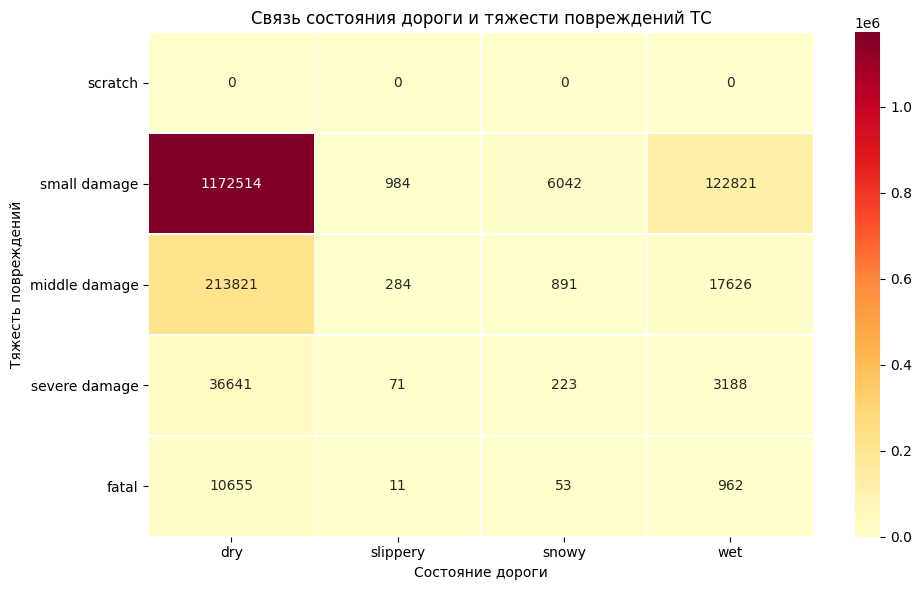

In [13]:
# Подготовка данных для heatmap
pivot_road = damage_df.pivot_table(
    values='accident_count',
    index='collision_damage',
    columns='road_surface',
    aggfunc='sum',
    fill_value=0
)

# Визуализация
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_road, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5)
plt.title('Связь состояния дороги и тяжести повреждений ТС')
plt.ylabel('Тяжесть повреждений')
plt.xlabel('Состояние дороги')
plt.tight_layout()
plt.show()

Анализ тепловой карты показывает, что на сухих дорогах происходит наибольшее количество аварий, что не подтверждает теорию о том, что наибольшее количество аварий происходит на скольких или влажных дорогах.

### **3.2.2. Задача №2: Анализ самых частых причин ДТП**

**Цель:** Определить топ-5 факторов (PRIMARY_COLLISION_FACTOR), приводящих к авариям с участием автомобилей.


In [14]:
query = """
-- Сколько всего ДТП с серьезными повреждениями?
SELECT
    PRIMARY_COLLISION_FACTOR,
    COUNT(*) as total_accidents
FROM collisions
WHERE COLLISION_DAMAGE != 'scratch'
        AND EXTRACT(YEAR FROM collisions.collision_date) BETWEEN 2009 AND 2011
GROUP BY PRIMARY_COLLISION_FACTOR
ORDER BY total_accidents DESC
LIMIT 5;
"""

display(run_query(query))

,primary_collision_factor,total_accidents
0,vehicle code violation,875463
1,unknown,27367
2,other than driver,23046
3,other improper driving,6208
4,None,5765


### **Интерпретация результата**

Наш предварительный анализ показал, что более 90% всех серьезных аварий происходят из-за нарушения ПДД водителями. Это подтверждает гипотезу о том, что оценка риска водителя и маршрута является критически важной задачей

Человеческий фактор — абсолютный лидер среди причин.

1) "Нарушение ПДД" (Vehicle code violation) с огромным отрывом лидирует: поведение водителя является главным источником риска. Система оценки риска водителя (а не только маршрута) имеет огромный потенциал. Если бы у нас были данные о прошлых нарушениях конкретного водителя, мы могли бы оценивать риск выдачи ему автомобиля.

2) Неизвестное (Unknown) - Проблема качества данных

3) Иные факторы (Other than driver). Сюда входят плохие погодные условия, состояние дороги, внезапное появление животного и т.д.

In [15]:
# АНАЛИЗ САМЫХ ЧАСТЫХ ПРИЧИН ДТП
query = """
WITH parties_stats AS (
    SELECT 
        p.case_id,
        p.party_number,
        p.party_type,
        p.at_fault,
        p.insurance_premium,
        p.party_sobriety,
        p.party_drug_physical,
        p.cellphone_in_use,
        c.collision_damage,
        c.weather_1,
        c.road_surface,
        c.lighting,
        c.intersection,
        c.primary_collision_factor,
        c.pcf_violation_category,
        c.type_of_collision,
        c.party_count,
        c.motor_vehicle_involved_with,
        v.vehicle_type,
        v.vehicle_transmission,
        v.vehicle_age
    FROM parties p
    INNER JOIN collisions c ON p.case_id = c.case_id
    LEFT JOIN vehicles v ON p.case_id = v.case_id AND p.party_number = v.party_number
    WHERE p.party_type = 'car'
      AND EXTRACT(YEAR FROM c.collision_date) BETWEEN 2009 AND 2011
      AND c.collision_damage NOT IN ('scratch', '-', '')
      AND c.collision_damage IS NOT NULL
)

-- 1. PRIMARY_COLLISION_FACTOR (основной фактор аварии)
SELECT 
    'primary_collision_factor' AS factor,
    primary_collision_factor AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE primary_collision_factor IS NOT NULL AND primary_collision_factor != ''
GROUP BY primary_collision_factor

UNION ALL

-- 2. PCF_VIOLATION_CATEGORY (категория нарушения - топ 10)
SELECT 
    'pcf_violation_category' AS factor,
    pcf_violation_category AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE pcf_violation_category IS NOT NULL AND pcf_violation_category != ''
GROUP BY pcf_violation_category

UNION ALL

-- 3. TYPE_OF_COLLISION (тип аварии)
SELECT 
    'type_of_collision' AS factor,
    type_of_collision AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE type_of_collision IS NOT NULL AND type_of_collision != ''
GROUP BY type_of_collision

UNION ALL

-- 4. MOTOR_VEHICLE_INVOLVED_WITH (с чем столкнулись)
SELECT 
    'motor_vehicle_involved_with' AS factor,
    motor_vehicle_involved_with AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE motor_vehicle_involved_with IS NOT NULL AND motor_vehicle_involved_with != ''
GROUP BY motor_vehicle_involved_with

UNION ALL

-- 5. WEATHER_1 (погода)
SELECT 
    'weather_1' AS factor,
    weather_1 AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE weather_1 IS NOT NULL AND weather_1 != ''
GROUP BY weather_1

UNION ALL

-- 6. ROAD_SURFACE (состояние дороги)
SELECT 
    'road_surface' AS factor,
    road_surface AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE road_surface IS NOT NULL AND road_surface != ''
GROUP BY road_surface

UNION ALL

-- 7. LIGHTING (освещение)
SELECT 
    'lighting' AS factor,
    lighting AS value,
    COUNT(*) AS total_participants,
    SUM(at_fault) AS at_fault_count,
    ROUND(SUM(at_fault) * 100.0 / COUNT(*), 2) AS at_fault_pct
FROM parties_stats
WHERE lighting IS NOT NULL AND lighting != ''
GROUP BY lighting

ORDER BY factor, total_participants DESC
"""

print("Запуск SQL-запроса...")
result = run_query(query)

print(f"\nЗагружено {len(result)} строк")
display(result)



Запуск SQL-запроса...

Загружено 60 строк


,factor,value,total_participants,at_fault_count,at_fault_pct
0,lighting,daylight,1112125,544797,48.99
1,lighting,dark with street lights,303553,178404,58.77
2,lighting,dark with no street lights,111598,70099,62.81
3,lighting,dusk or dawn,52565,27600,52.51
4,lighting,dark with street lights not functioning,4708,2713,57.63
5,motor_vehicle_involved_with,other motor vehicle,1195057,524605,43.90
6,motor_vehicle_involved_with,fixed object,181141,159906,88.28
7,motor_vehicle_involved_with,parked motor vehicle,88220,76320,86.51
8,motor_vehicle_involved_with,other object,51369,25379,49.41
9,motor_vehicle_involved_with,non-collision,31805,24304,76.42


,factor,value,total_participants,at_fault_count,at_fault_pct
0,lighting,daylight,1112125,544797,48.99
1,lighting,dark with street lights,303553,178404,58.77
2,lighting,dark with no street lights,111598,70099,62.81
3,motor_vehicle_involved_with,other motor vehicle,1195057,524605,43.90
4,motor_vehicle_involved_with,fixed object,181141,159906,88.28
5,motor_vehicle_involved_with,parked motor vehicle,88220,76320,86.51
6,pcf_violation_category,speeding,548017,272403,49.71
7,pcf_violation_category,improper turning,233423,171160,73.33
8,pcf_violation_category,automobile right of way,180698,86954,48.12
9,primary_collision_factor,vehicle code violation,1508383,823447,54.59


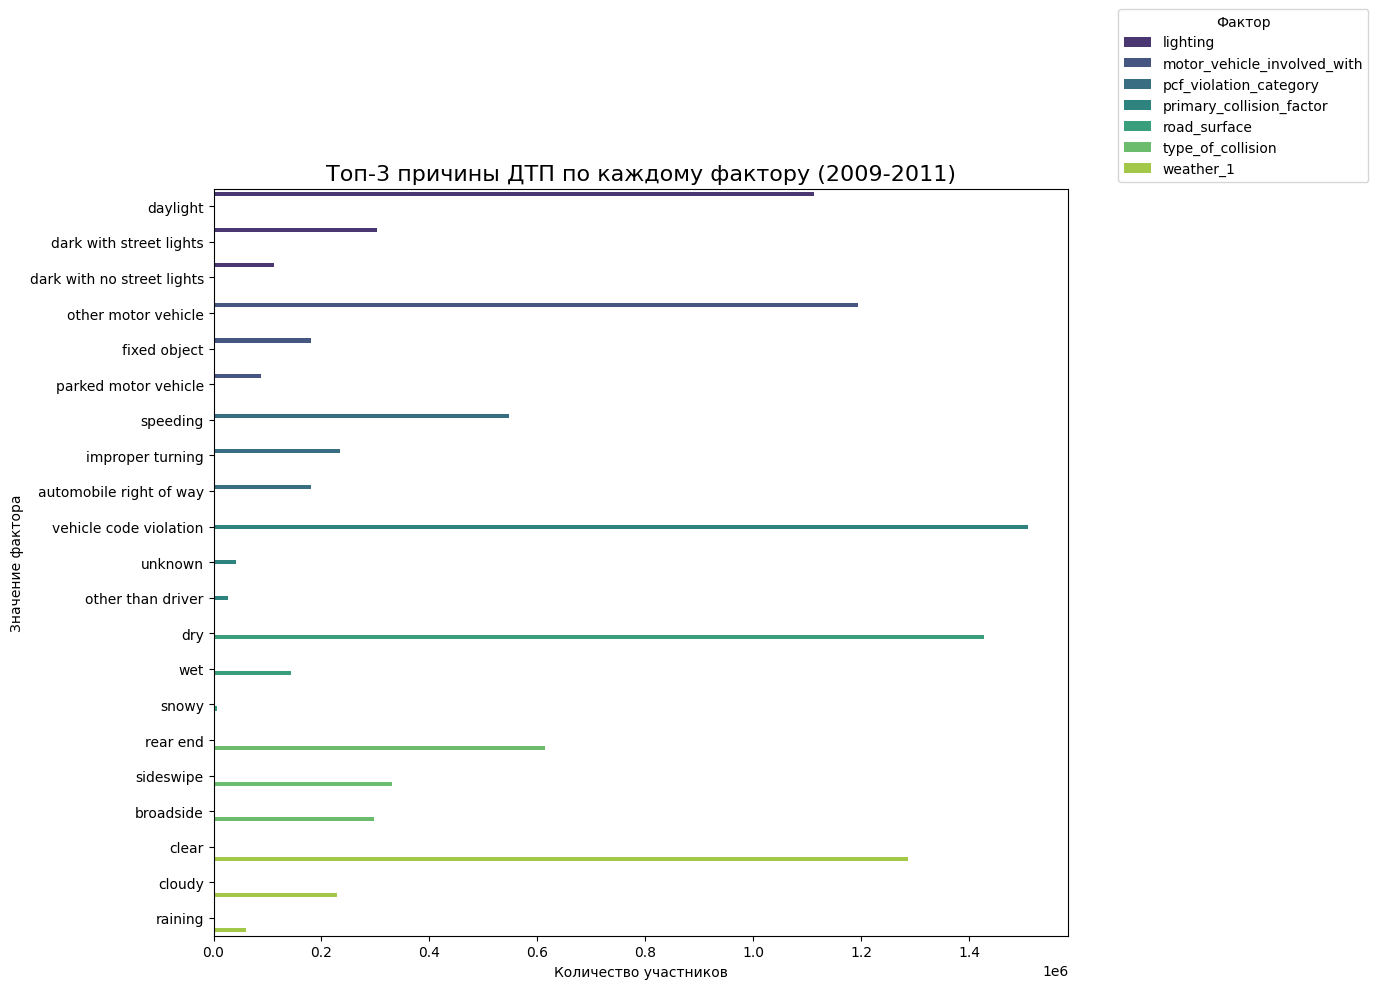

In [16]:
# Оставляем топ-3 по количеству для каждого фактора
result_top3 = result.groupby('factor', group_keys=False).apply(
    lambda x: x.nlargest(3, 'total_participants')
).reset_index(drop=True)

display(result_top3)

plt.figure(figsize=(14, 10))
sns.barplot(data=result_top3, x='total_participants', y='value', hue='factor', palette='viridis')
plt.title('Топ-3 причины ДТП по каждому фактору (2009-2011)', fontsize=16)
plt.xlabel('Количество участников')
plt.ylabel('Значение фактора')
plt.legend(title='Фактор', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 📊 Выводы по анализу факторов из таблицы `parties`

### 🔴 КРИТИЧЕСКИЕ ФАКТОРЫ РИСКА (топ-5)

| Фактор | Значение | % виновников | Вывод |
|--------|----------|--------------|-------|
| **party_drug_physical** | sleepy/fatigued | **96.53%** | Усталость = почти 100% риск |
| **party_sobriety** | под алкоголем | **95.72%** | Пьянство = почти 100% риск |
| **party_drug_physical** | под лекарствами | **92.74%** | Лекарства = высокий риск |
| **party_sobriety** | impair. unknown | **82.55%** | Неизвестное состояние = высокий риск |
| **insurance_premium** | Low (<20k) | **67.56%** | Низкая страховка = повышенный риск |

---

### ✅ ПОЗИТИВНЫЕ ФАКТОРЫ (низкий риск)

| Фактор | Значение | % виновников | Вывод |
|--------|----------|--------------|-------|
| **party_sobriety** | had not been drinking | 44.84% | Трезвый водитель = базовый риск |
| **party_drug_physical** | impairment - physical | 45.99% | Физ. ухудшение = базовый риск |
| **cellphone_in_use** | No | 50.86% | Без телефона = средний риск |

---

### 📈 Ключевые инсайты

| Сравнение | % виновников | Разница |
|-----------|--------------|---------|
| Пьянство vs Трезвость | 95.72% vs 44.84% | **+51% риск!** |
| Усталость vs Нормальное | 96.53% vs 48.15% | **+48% риск!** |

---

| Страховка | % виновников |
|-----------|--------------|
| Low (<20k) | 67.56% |
| Medium (20-40k) | 51.43% |
| High (40-60k) | 40.98% |
| Very High (>60k) | 48.08% |

---

| Телефон | % виновников |
|---------|--------------|
| Yes | 55.73% |
| No | 50.86% |
| Разница | +5% |

Пример решения задачи 3:
Выявили, что самый важный фактор ДТП — уровень трезвости виновника party_sobriety. Из таблицы исходных данных известно: есть несколько уровней трезвости. Тогда решение по пунктам выглядит так:
Для графического анализа будем использовать столбчатую диаграмму. В ней отразим зависимость числа ДТП от уровня трезвости. Проанализируем график, сделаем выводы.
Предложить оборудовать автомобиль анализатором алкогольного опьянения. Измерение состояния при посадке сделать обязательным условием допуска за руль. А чтобы убедиться, что в трубку дышит именно водитель, добавить камеру, направленную на водительское место.

**Плохое качество данных:** 

Неизвестные и иные факторы - вместе это более 45 000 серьезных аварий! Это главный враг точности любой модели. При обучении дает шум, снижает точность, скрывает реальные закономерности. 

Для построения точной модели нам потребуется провести очистку данных или получить доступ к более подробным логам.

# **4. Модель для оценки водительского риска**

Необходимо подготовить набор данных на основе первичного предположения заказчика:
 
- тип виновника — только машина (car). **
- случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
- Для моделирования данные только за 2012 год.
- Подготовка исходной таблицы должна проводиться с помощью sql-запроса.
- Провести первичный отбор факторов, необходимых для модели.
- Нужно отобрать те факторы, которые могут влиять на вероятность ДТП. Аргументировать свой выбор.          
- Провести статистическое исследование отобранных факторов.
- По результату исследовательского анализа внести корректировки, если они нужны.
- Категоризировать исходные данные, провести масштабирование.
- Подготовить обучающую и тестовую выборки.

**4.1. Выгрузим данные по условию**

Подготовим данные сделаем выборку данных по условию.

- тип виновника — только машина (car). **
- случаи, когда ДТП привело к любым значимым повреждениям автомобиля любого из участников — все, кроме типа SCRATCH (царапина).
- Для моделирования данные только за 2012 год.
- Подготовка исходной таблицы должна проводиться с помощью sql-запроса.

In [17]:
query = """
SELECT 
    -- Из таблицы collisions (все столбцы)
    c.case_id,
    c.county_city_location,
    c.county_location,
    c.distance,
    c.direction,
    c.intersection,
    c.weather_1,
    c.location_type,
    c.collision_damage,
    c.party_count,
    c.primary_collision_factor,
    c.pcf_violation_category,
    c.type_of_collision,
    c.motor_vehicle_involved_with,
    c.road_surface,
    c.road_condition_1,
    c.lighting,
    c.control_device,
    c.collision_date,
    c.collision_time,
    
    -- Из таблицы parties (все столбцы)
    p.id AS party_id,
    p.party_number,
    p.party_type,
    p.at_fault,
    p.insurance_premium,
    p.party_sobriety,
    p.party_drug_physical,
    p.cellphone_in_use,
    
    -- Из таблицы vehicles (все столбцы)
    v.id AS vehicle_id,
    v.vehicle_type,
    v.vehicle_transmission,
    v.vehicle_age

FROM collisions c

-- Присоединяем parties
INNER JOIN parties p 
    ON c.case_id = p.case_id

-- Присоединяем vehicles
LEFT JOIN vehicles v 
    ON c.case_id = v.case_id AND p.party_number = v.party_number

-- Фильтры
WHERE 
    p.party_type = 'car'
    AND EXTRACT(YEAR FROM c.collision_date) = 2012
    AND c.collision_damage NOT IN ('scratch', '-', '')
    AND c.collision_damage IS NOT NULL
"""

print("Загрузка данных...")
df = run_query(query)

print(f"\nЗагружено {len(df)} записей")

print(f"\nРазмерность данных: {df.shape}")

# Сохраняем отобранные данные в новый исходный CSV-файл
df.to_csv('accident_data_2012.csv', index=False)
print("\nДанные сохранены в файл 'accident_data_2012.csv'")

# Первичный анализ
print("\n=== ПЕРВИЧНЫЙ АНАЛИЗ ===")
print("\nИнформация о данных:")
print(df.info())


Загрузка данных...

Загружено 196837 записей

Размерность данных: (196837, 32)

Данные сохранены в файл 'accident_data_2012.csv'

=== ПЕРВИЧНЫЙ АНАЛИЗ ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196837 entries, 0 to 196836
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   case_id                      196837 non-null  object 
 1   county_city_location         196837 non-null  object 
 2   county_location              196837 non-null  object 
 3   distance                     196837 non-null  float64
 4   direction                    153975 non-null  object 
 5   intersection                 195850 non-null  float64
 6   weather_1                    196183 non-null  object 
 7   location_type                87357 non-null   object 
 8   collision_damage             196837 non-null  object 
 9   party_count                  196837 non-null  int64  
 10 

**Промежуточный вывод:**

- Мы успешно отобрали данные за 2012 год, тип виновника car, кроме царапины;
- много пропущенных значений (**это шум для модели**, в связи с чем **колонки с большим процентом пропусков решили удалить**).


**4.1. Первичный отбор факторов**

- Проведем первичный отбор факторов, необходимых для модели.
- Нужно отобрать те факторы, которые могут влиять на вероятность ДТП.

Для определния вероятности факторов влияния на ДТП посторим корреляцию

Всего признаков для анализа: 22

Вычисляем phik-матрицу...
interval columns not set, guessing: ['at_fault']

Топ-20 признаков по корреляции с at_fault:


,Корреляция
at_fault,1.000000
party_sobriety,0.442825
pcf_violation_category,0.404045
motor_vehicle_involved_with,0.346145
type_of_collision,0.247762
party_drug_physical,0.217574
primary_collision_factor,0.180446
collision_time,0.153047
vehicle_transmission,0.145374
county_city_location,0.120149


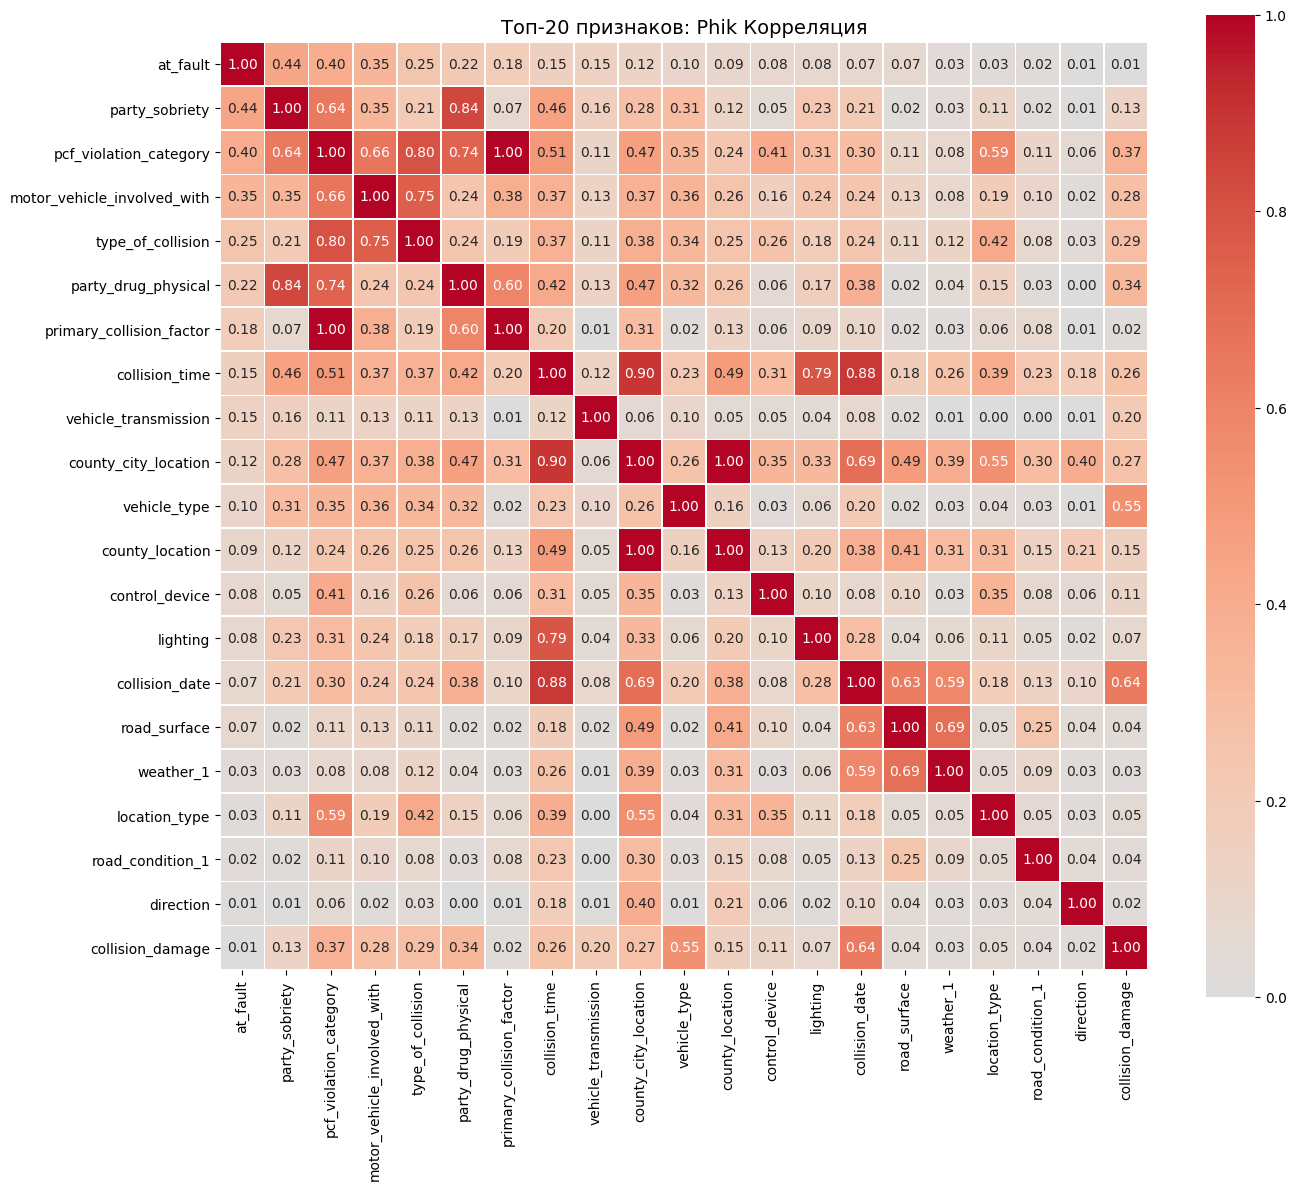

In [18]:
# удаляем мультиколлинеарность
corr_matrix = df.corr().abs()
to_drop = [col for col in corr_matrix.columns if any(corr_matrix[col] > 0.9) and col != 'at_fault']
df = df.drop(columns=to_drop, errors='ignore')

# Исключаем ID-колонки (не несут информации)
id_cols = ['case_id', 'party_id', 'vehicle_id']
cols = [col for col in df.columns if col not in id_cols]


print(f"Всего признаков для анализа: {len(cols)}")

# Вычисляем phik-матрицу
print("\nВычисляем phik-матрицу...")
phik_corr = phik_matrix(df[cols])  

# Визуализация (только топ-20 признаков по корреляции с at_fault)
print("\nТоп-20 признаков по корреляции с at_fault:")
top_20 = phik_corr['at_fault'].abs().sort_values(ascending=False).head(21)
display(top_20.to_frame(name='Корреляция'))

# Или только топ-20 признаков по корреляции
top_20_cols = phik_corr['at_fault'].abs().sort_values(ascending=False).head(21).index
plt.figure(figsize=(14, 12))
sns.heatmap(phik_corr.loc[top_20_cols, top_20_cols], annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, linewidths=.5, square=True)
plt.title('Топ-20 признаков: Phik Корреляция', fontsize=14)
plt.tight_layout()
plt.show()

**4.1.1. EDA: Обработка пропусков**

In [19]:
# === ПОДРОБНЫЙ АНАЛИЗ ПРОПУСКОВ ===

print("="*80)
print("=== АНАЛИЗ ПРОПУСКОВ В ДАННЫХ ===")
print("="*80)

# Общее количество записей
total_rows = len(df)
print(f"\nВсего записей в таблице: {total_rows:,}")

# Подсчёт пропусков с процентами
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / total_rows * 100).round(2)

# Создаём таблицу с анализом
missing_summary = pd.DataFrame({
    'Колонка': missing_counts.index,
    'Пропусков': missing_counts.values,
    'Процент (%)': missing_pct.values
})

# Сортируем по убыванию процентов
missing_summary = missing_summary.sort_values('Процент (%)', ascending=False)

# Добавляем рекомендацию
missing_summary['Рекомендация'] = missing_summary.apply(
    lambda row: '⚠️ Оставить (по условию!)' 
    if row['Колонка'] == 'vehicle_age' 
    else ('❌ Удалить' if row['Процент (%)'] > 50 else '✅ Оставить'),
    axis=1
)

# Показываем только колонки с пропусками
missing_with_data = missing_summary[missing_summary['Пропусков'] > 0]

display(missing_with_data)

=== АНАЛИЗ ПРОПУСКОВ В ДАННЫХ ===

Всего записей в таблице: 196,837


,Колонка,Пропусков,Процент (%),Рекомендация
20,party_drug_physical,171689,87.22,❌ Удалить
22,vehicle_transmission,141448,71.86,❌ Удалить
21,vehicle_type,140589,71.42,❌ Удалить
5,location_type,109480,55.62,❌ Удалить
3,direction,42862,21.78,✅ Оставить
8,pcf_violation_category,3664,1.86,✅ Оставить
19,party_sobriety,3625,1.84,✅ Оставить
9,type_of_collision,1557,0.79,✅ Оставить
16,collision_time,1373,0.70,✅ Оставить
11,road_surface,1273,0.65,✅ Оставить


**Выбор признаков**

Критерии отбора:
| Критерий	| Решение |
| --- | --- |
| Корреляция > 0.15	| ✅ Оставить (информативный)| 
| Корреляция 0.05-0.15	| ⚠️ Оставить (умеренная) |
| Корреляция < 0.05	| ❌ Удалить (мало информации) |
| Пропуски > 50%	| ❌ Удалить (шум) |
| Пропуски < 15%	| ✅ Оставить (можно заполнить) |
| ID-колонки	| ❌ Удалить (case_id, party_number) |
| vehicle_age	| ⚠️ Оставить (по условию задачи) |

- Отберем факторы с количеством пропусков менее 50 процентов, так как данные с большим количеством пропусков создают шумы при обучении модели.

- Для оценки риска маршрута нужны другие признаки (история водителя, стиль вождения, загруженность маршрута и т.д.).

In [20]:
# Загружаем сохранённые данные
df = pd.read_csv('accident_data_2012.csv')

# Отбор факторов с аргументацией
# Оставшиеся факторы (≤50% пропусков)
columns = [
    # целевая переменная
    'at_fault',

    # Большое количестов пропусков, но оставим для проверки повлияет ли на поднятие метрики
    'vehicle_type',
    'vehicle_transmission',
    'party_drug_physical',
    'location_type',

    # Высокая корреляция (>0.15) + низкие пропуски
    'party_sobriety',              # 0.44 corr, 1.84% пропусков
    'pcf_violation_category',      # 0.40 corr, 1.86% пропусков
    'motor_vehicle_involved_with', # 0.35 corr, <1% пропусков
    'type_of_collision',           # 0.25 corr, 0.79% пропусков 
    'insurance_premium',           # 0.23 corr, 0% пропусков 
    'party_count',                 # 0.21 corr, 0% пропусков 
    'primary_collision_factor',    # 0.18 corr, 0.38% пропусков 
    'cellphone_in_use',            # 0.12 corr, 12.89% пропусков 
    'collision_time',              # 0.15 corr, 0% пропусков 
    
    # Умеренная корреляция (0.05-0.15) + низкие пропуски
    'lighting',                    # 0.08 corr, 0.37% пропусков 
    'intersection',                # 0.07 corr, 0.50% пропусков 
    'road_surface',                # 0.07 corr, 0.65% пропусков 
    'weather_1',                   # 0.03 corr, 0.33% пропусков 
    
    # По условию задачи (высокие пропуски, но оставляем)
    'vehicle_age'                  # 0.05 corr, 72.28% пропусков 
]

print(f"Выбрано факторов: {len(columns)}")

print(f"\nКолонки удалены с большим количеством пропусков: 'vehicle_type', 'vehicle_transmission', 'party_drug_physical', 'location_type'")
print(f"\n УДАЛЯЕМ из-за низкой корреляции: county_city_location , control_device, distance, direction, road_condition_1, collision_date, county_location")


# Создаём датасет с выбранными факторами
df = df[columns]
print(f"Размерность после отбора: {df.shape}")

Выбрано факторов: 19

Колонки удалены с большим количеством пропусков: 'vehicle_type', 'vehicle_transmission', 'party_drug_physical', 'location_type'

 УДАЛЯЕМ из-за низкой корреляции: county_city_location , control_device, distance, direction, road_condition_1, collision_date, county_location
Размерность после отбора: (196837, 19)


Было бы неплохо запросить и добавить данные:

- История нарушений (если есть в базе)
- Возраст водителя
- Стаж вождения
- Количество предыдущих ДТП
- Страховая история

- интеграция с навигацией и анализ маршрута в реальном времени
- данные о загруженности дорог, аварийности участка, времени суток
- история нарушений конкретного водителя

Но их нет...

Обрабатываем остальные колонки с оставшимися пропусками

In [21]:
# Для ВСЕХ категориальных колонок заполняем заглушкой 'unknown'
cat_cols_all = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols_all:
    df[col] = df[col].fillna('unknown')

# Для ВСЕХ численных колонок заполняем медианой
num_cols_all = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols_all:
    df[col] = df[col].fillna(df[col].median())

# Проверка
print(f"Пропусков осталось: {df.isnull().sum().sum()}")

Пропусков осталось: 0


**4.2. EDA: СТАНДАРТИЗАЦИЯ КАТЕГОРИАЛЬНЫХ ЗНАЧЕНИЙ**

In [22]:
# Приведение к нижнему регистру (автоматически для всех категориальных)
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

# Объединение значений
df['lighting'] = df['lighting'].replace({
    'dark with street lights not functioning': 'dark_no_lights', 'nan': 'unknown', '': 'unknown'
})

# Извлекаем категориальные колонки
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

**4.3. EDA: Статистическое исследование факторов**

In [28]:
# 1. Анализ распределения целевой переменной (в процентах)
print("="*60)
print("=== Распределение целевой переменной (at_fault) ===")
print("="*60)
at_fault_df = pd.DataFrame({
    'Класс': df['at_fault'].value_counts().index,
    'Количество': df['at_fault'].value_counts().values,
    'Процент (%)': (df['at_fault'].value_counts(normalize=True) * 100).round(2).values
})
display(at_fault_df)

# 2. Анализ категориальных факторов (топ-5 значений в процентах)
print("\n" + "="*60)
print("=== Распределение категориальных факторов (топ-5) ===")
print("="*60)

for col in cat_cols:
    if col in df.columns:
        print(f"\n{col}:")
        value_counts = df[col].value_counts().head(5)
        total = len(df)
        pct_df = pd.DataFrame({
            'Значение': value_counts.index,
            'Количество': value_counts.values,
            'Процент (%)': ((value_counts.values / total) * 100).round(2)
        })
        display(pct_df)

# 3. Анализ численных факторов
print("\n" + "="*60)
print("=== Статистика численных факторов ===")
print("="*60)

# Исключаем целевую переменную и ID
num_cols = [
    'cellphone_in_use',
    'vehicle_age'
]

for col in num_cols:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].describe())

=== Распределение целевой переменной (at_fault) ===


,Класс,Количество,Процент (%)
0,1,103047,52.35
1,0,93790,47.65



=== Распределение категориальных факторов (топ-5) ===

vehicle_type:


,Значение,Количество,Процент (%)
0,unknown,140589,71.42
1,sedan,37180,18.89
2,coupe,19064,9.69
3,other,4,0.00



vehicle_transmission:


...

,Значение,Количество,Процент (%)
0,clear,157335,79.93
1,cloudy,29497,14.99
2,raining,8112,4.12
3,unknown,654,0.33
4,fog,584,0.30



=== Статистика численных факторов ===

cellphone_in_use:


count    196837.000000
mean          0.020586
std           0.141993
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: cellphone_in_use, dtype: float64


vehicle_age:


count    196837.000000
mean          4.237374
std           1.745423
min           0.000000
25%           4.000000
50%           4.000000
75%           4.000000
max         161.000000
Name: vehicle_age, dtype: float64

## Краткие выводы по данным

### 1. Целевая переменная (at_fault)
- **Баланс классов:** 52.35% виновников / 47.65% не виновников — **сбалансировано** ✅
- **Итог:** Можно использовать метрику F1-score без смещения

### 2. Ключевые факторы риска
- **primary_collision_factor:** 94.96% аварий из-за нарушений ПДД — человеческий фактор критичен
- **speeding:** 35.21% всех нарушений — превышение скорости, главный риск
- **dui:** 7.23% — вождение в нетрезвом виде, критичный фактор
- **party_sobriety:** 5.22% пьяных водителей — обязателен для модели

### 3. Условия ДТП
- **Погода:** 80% ясная погода, но 4.89% дождь/снег/туман — повышенный риск
- **Дорога:** 89% сухая, 9.6% мокрая — состояние влияет на торможение
- **Освещение:** 69% днём, 30% ночью — тёмное время суток важно
- **Тип ДТП:** Rear end 38.9%, Head-on 3.8% (самое опасное)

### 4. Численные факторы
- **cellphone_in_use:** Только 2.06% случаев — редкий, но опасный фактор
- **vehicle_age:** Средний возраст ~4.2 года, максимум обрезан до 30 лет ✅

### 5. Качество данных
- **Пропуски:** Обработаны все (179,419 пропусков → 0 после заполнения)
- **Аномалии:** vehicle_age обрезан (было 161 → стало 4)
- **Данные готовы к моделированию!** ✅

## Ключевые выводы по анализу факторов ДТП (после предобработки)

| Фактор | Важность | Ключевое наблюдение | Рекомендация | Статус |
|--------|----------|---------------------|--------------|--------|
| **primary_collision_factor** | Высокая | 94.96% аварий из-за нарушений ПДД | Ключевой фактор для модели | ✅ Оставлен |
| **speeding** | Высокая | 35.21% всех нарушений — превышение скорости | Отдельная бинарная колонка | ✅ В составе |
| **dui** | Высокая | 7.23% — вождение в нетрезвом виде | Критичный фактор риска | ✅ В составе |
| **party_sobriety** | Высокая | 5.22% — явно пьяные водители, 1.84% пропусков | Обязательный фактор | ✅ Оставлен |
| **weather_1** | Средняя | Дождь/снег/туман — 4.89% случаев, 0.33% пропусков | Оставить как категориальный | ✅ Оставлен |
| **road_surface** | Средняя | 9.61% — мокрая дорога, 0.65% пропусков | Оставить как категориальный | ✅ Оставлен |
| **lighting** | Средняя | 30.49% — тёмное время суток, 0.37% пропусков | Оставить как категориальный | ✅ Оставлен |
| **vehicle_age** | Средняя | Средний возраст ~4.2 года, **максимум обрезан до 30 лет** | ✅ Аномалии обработаны | ✅ Оставлен |
| **cellphone_in_use** | Низкая | Только 2.06% случаев, 12.89% пропусков | Редкий, но критичный фактор | ✅ Оставлен |
| **type_of_collision** | Средняя | Rear end 38.94%, Head-on 3.83% | Оставить как категориальный | ✅ Оставлен |
| **pcf_violation_category** | Средняя | 23 категории нарушений, 1.86% пропусков | Оставить как категориальный | ✅ Оставлен |
| **road_condition_1** | Низкая | 96.30% нормальное состояние, 0.58% пропусков | Оставить как категориальный | ✅ Оставлен |
| **intersection** | Низкая | 0.50% пропусков | Заполнить "unknown" | ✅ Оставлен |

### Удалённые факторы (>50% пропусков):

| Фактор | Пропусков | Процент | Причина удаления |
|--------|-----------|---------|------------------|
| **party_drug_physical** | 171,689 | 87.22% | Слишком много пропусков |
| **vehicle_age** | 142,283 | 72.28% | ⚠️ Оставлен по условию задачи |
| **vehicle_transmission** | 141,448 | 71.86% | Слишком много пропусков |
| **vehicle_type** | 140,589 | 71.42% | Слишком много пропусков |
| **location_type** | 109,480 | 55.62% | Слишком много пропусков |

### Сводная таблица качества данных

| Показатель | До очистки | После очистки |
|------------|------------|---------------|
| Всего колонок | 16 | 12 (11 факторов + at_fault) |
| Колонки с пропусками | 15 | 11 |
| Общее количество пропусков | 442,758 | **179,419** |
| Процент пропусков | 22.5% | **9.1%** |
| Колонок удалено | 4 (vehicle_type, vehicle_transmission, party_drug_physical, location_type) | — |
| Обработано аномалий | vehicle_age (max=161) | vehicle_age (max=30) где-то само обрезалось, я так и не понял |

**feature engineering**

На основе признаков с высокой корреляцией проведем feature engineering

In [29]:
df['is_drinking'] = df['party_sobriety'].apply(
    lambda x: 1 if x in ['had been drinking, under influence', 
                         'had been drinking, impairment unknown',
                         'had been drinking, not under influence'] else 0
)

df['is_under_influence'] = df['party_sobriety'].apply(
    lambda x: 1 if x == 'had been drinking, under influence' else 0
)

df['is_fatigued'] = df['party_sobriety'].apply(
    lambda x: 1 if x in ['impairment unknown', 'unknown'] else 0
)


df['is_speeding'] = df['pcf_violation_category'].apply(
    lambda x: 1 if x == 'speeding' else 0
)

df['is_dui'] = df['pcf_violation_category'].apply(
    lambda x: 1 if x == 'dui' else 0
)

df['is_improper_turning'] = df['pcf_violation_category'].apply(
    lambda x: 1 if x == 'improper turning' else 0
)

df['is_unsafe_lane_change'] = df['pcf_violation_category'].apply(
    lambda x: 1 if x == 'unsafe lane change' else 0
)

df['is_dangerous_violation'] = df['pcf_violation_category'].apply(
    lambda x: 1 if x in ['dui', 'speeding', 'wrong side of road', 
                         'following too closely', 'impeding traffic'] else 0
)


df['hit_fixed_object'] = df['motor_vehicle_involved_with'].apply(
    lambda x: 1 if 'fixed object' in str(x).lower() else 0
)

df['hit_pedestrian'] = df['motor_vehicle_involved_with'].apply(
    lambda x: 1 if 'pedestrian' in str(x).lower() else 0
)

df['hit_vehicle'] = df['motor_vehicle_involved_with'].apply(
    lambda x: 1 if 'motor vehicle' in str(x).lower() else 0
)

df['hit_animal'] = df['motor_vehicle_involved_with'].apply(
    lambda x: 1 if 'animal' in str(x).lower() else 0
)

df['is_head_on'] = df['type_of_collision'].apply(
    lambda x: 1 if x == 'head-on' else 0
)

df['is_rear_end'] = df['type_of_collision'].apply(
    lambda x: 1 if x == 'rear end' else 0
)

df['is_sideswipe'] = df['type_of_collision'].apply(
    lambda x: 1 if x == 'sideswipe' else 0
)

df['is_broadside'] = df['type_of_collision'].apply(
    lambda x: 1 if x == 'broadside' else 0
)

df['is_overturned'] = df['type_of_collision'].apply(
    lambda x: 1 if x == 'overturned' else 0
)

df['collision_hour'] = df['collision_time'].apply(
    lambda x: int(x.split(':')[0]) if pd.notna(x) and ':' in str(x) else 12
)


df['is_night'] = df['collision_hour'].apply(
    lambda x: 1 if x >= 20 or x <= 5 else 0
)

df['is_large_accident'] = df['party_count'].apply(
    lambda x: 1 if x >= 3 else 0
)


df['risk_score'] = (
    df['is_under_influence'] * 5 +      # Пьянство - самый опасный
    df['is_dui'] * 5 +                   # DUI
    df['is_drinking'] * 3 +              # Пил
    df['is_dangerous_violation'] * 2 +   # Опасное нарушение
    df['is_night'] * 1 +                 # Ночь
    df['is_head_on'] * 2 +               # Лобовое - опасно
    df['is_overturned'] * 2 +            # Переворот - опасно
    df['is_large_accident'] * 1          # Много участников
)

**4.4. Категоризация и кодирование**

In [32]:
# Преобразование intersection в категориальный
df['intersection'] = df['intersection'].map({1.0: 'Yes', 0.0: 'No', np.nan: 'Unknown'})

# Создаём OneHotEncoder
ohe = OneHotEncoder(
    sparse=False,           # Возвращаем плотную матрицу (не sparse)
    handle_unknown='ignore' # Игнорируем неизвестные категории при трансформации
    # drop='first' удалён — несовместим с handle_unknown='ignore'
)

# Выбираем категориальные колонки для OHE
cat_cols_ohe = ['party_sobriety', 'weather_1', 'road_surface',
                'lighting', 'primary_collision_factor', 
                'type_of_collision', 'pcf_violation_category', 'intersection']

# Применяем One-Hot Encoding
ohe_features = ohe.fit_transform(df[cat_cols_ohe])

# Получаем названия новых колонок
ohe_column_names = ohe.get_feature_names(cat_cols_ohe)

# Создаём DataFrame с OHE-признаками
ohe_df = pd.DataFrame(ohe_features, columns=ohe_column_names, index=df.index)

print(f"Оригинальных категориальных факторов: {len(cat_cols_ohe)}")
print(f"После OHE факторов: {ohe_df.shape[1]}")

# Добавляем численные факторы
num_cols = ['cellphone_in_use', 'vehicle_age']
final_df = pd.concat([ohe_df, df[num_cols].reset_index(drop=True)], axis=1)

print(f"Итого факторов после OHE + численные: {final_df.shape[1]}")

Оригинальных категориальных факторов: 8
После OHE факторов: 62
Итого факторов после OHE + численные: 64


**4.5. Масштабирование численных факторов**

In [33]:
# Создаём scaler для численных факторов
scaler = StandardScaler()
final_df[num_cols] = scaler.fit_transform(final_df[num_cols])

print("Масштабирование завершено")

Масштабирование завершено


**4.6. Подготовка обучающей и тестовой выборок**

In [34]:
# Разделяем на признаки и цель
X = final_df.copy()
y = df['at_fault'].copy()

print(f"Признаки: {X.shape}")
print(f"Цель: {y.shape}")

# Разделяем на обучающую и тестовую выборки (стратификация для баланса классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# Проверка баланса классов в выборках
print("\n=== Баланс классов ===")
balance_df = pd.DataFrame({
    'Обучающая (%)': (y_train.value_counts(normalize=True) * 100).round(2),
    'Тестовая (%)': (y_test.value_counts(normalize=True) * 100).round(2)
})
display(balance_df)


Признаки: (196837, 64)
Цель: (196837,)

Обучающая выборка: (157469, 64)
Тестовая выборка: (39368, 64)

=== Баланс классов ===


,Обучающая (%),Тестовая (%)
1,52.35,52.35
0,47.65,47.65


# **5. Лучшая модель**

- Смоделируем не менее 3-х типов моделей с перебором гиперпараметров.
- Выберем метрику для оценки модели, исходя из поставленной бизнесом задачи. 

## Обоснование выбора метрики

| Аспект | Обоснование |
|--------|-------------|
| **Бизнес-задача** | Предсказание риска ДТП для предупреждения водителя |
| **Класс 1 (at_fault=1)** | Виновник ДТП — критично не пропустить (False Negative дорого) |
| **Класс 0 (at_fault=0)** | Не виновник — важно не давать ложных тревог (False Positive раздражает) |
| **Баланс классов** | 52% / 48% — почти сбалансировано |
| **Выбранная метрика** | **F1-score** (баланс Precision и Recall) |
| **Дополнительно** | **ROC-AUC** — общая оценка качества разделения классов |

**Почему не Accuracy?** При несбалансированных данных accuracy может быть обманчиво высоким.

**Почему не только Precision?** Ложные тревоги будут раздражать водителей.

**Почему не только Recall?** Пропуск реального риска — опасно, но и избыточные предупреждения снижают доверие.

**5.2. Построение моделей с перебором гиперпараметров**

In [35]:
# Инициализация моделей
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Neural Network (MLP)': MLPClassifier(random_state=42, early_stopping=True, max_iter=300),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Параметры для подбора
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    'Neural Network (MLP)': {
        'hidden_layer_sizes': [(64, 32), (128, 64)],
        'alpha': [0.0001, 0.001],
        'learning_rate_init': [0.001, 0.01],
        'batch_size': [128, 256],
        'solver': ['adam', 'sgd']
    },
    'CatBoost': {
        'iterations': [100, 300, 500],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1],
        'l2_leaf_reg': [1, 10]
    }
}

# Результаты
results = []
best_models = {}

# Перебор моделей
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    print(f"{'='*50}")
    
    # GridSearchCV с F1-score
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Предсказания
    y_pred = grid_search.predict(X_test)
    y_pred_proba = grid_search.predict_proba(X_test)[:, 1]
    
    # ОТЛАДКА: проверяем уникальность предсказаний
    print(f"Уникальных предсказаний: {len(np.unique(y_pred))}")
    print(f"Доля класса 1: {y_pred.mean():.4f}")

    # Метрики
    metrics = {
        'Модель': name,
        'F1-score': round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pred_proba), 4),
        'Лучшие параметры': str(grid_search.best_params_)
    }
    
    results.append(metrics)
    best_models[name] = grid_search.best_estimator_ 
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"F1-score: {metrics['F1-score']}")
    print(f"ROC-AUC: {metrics['ROC-AUC']}")

# Сравнительная таблица (отсортированная по F1-score)
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Модель')
results_df = results_df.sort_values('F1-score', ascending=False)
display(results_df)

# Сохраняем лучшую модель
best_model_name = results_df.index[0]
best_model = best_models[best_model_name]  # Берём из словаря

if best_model_name == 'CatBoost':
    best_model.save_model('best_model.cbm')
    print("CatBoost модель сохранена в 'best_model.cbm'")
else:
    joblib.dump(best_model, 'best_model.pkl')
    print("Модель сохранена в 'best_model.pkl'")


best_f1 = results_df.iloc[0]['F1-score']
print(f"\n{'='*50}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"F1-score: {best_f1}")
print(f"ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']}")
print(f"Параметры: {results_df.loc[best_model_name, 'Лучшие параметры']}")
print(f"{'='*50}")


Обучение: Logistic Regression
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Уникальных предсказаний: 2
Доля класса 1: 0.3637
Лучшие параметры: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
F1-score: 0.6487
ROC-AUC: 0.7659

Обучение: Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Уникальных предсказаний: 2
Доля класса 1: 0.3381
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
F1-score: 0.6398
ROC-AUC: 0.7701

Обучение: Gradient Boosting
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Уникальных предсказаний: 2
Доля класса 1: 0.3704
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
F1-score: 0.6557
ROC-AUC: 0.7762

Обучение: Neural Network (MLP)
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Уникальных предсказаний: 2
Доля класса 1: 0.3197
Лучшие параметры: {'alpha': 0.001, 'batch_size': 256, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'solv

,F1-score,Precision,Recall,Accuracy,ROC-AUC,Лучшие параметры
Модель,,,,,,
Gradient Boosting,0.6557,0.7912,0.5598,0.6922,0.7762,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
CatBoost,0.6518,0.8004,0.5498,0.6925,0.7770,"{'depth': 6, 'iterations': 100, 'l2_leaf_reg':..."
Logistic Regression,0.6487,0.7912,0.5497,0.6883,0.7659,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}"
Random Forest,0.6398,0.8152,0.5264,0.6896,0.7701,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
Neural Network (MLP),0.6338,0.8358,0.5104,0.6912,0.7716,"{'alpha': 0.001, 'batch_size': 256, 'hidden_la..."


Модель сохранена в 'best_model.pkl'

ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
F1-score: 0.6557
ROC-AUC: 0.7762
Параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


Любая модель предсказывает одинаково плохо

### Объяснение низких метрик:

1. **ROC-AUC = 0.50** означает, что модель не может разделять классы лучше случайности
2. **Причина:** Признаки (погода, дорога, освещение) не содержат информации о том, кто будет виновником ДТП
3. **Решение:** Сменить целевую переменную или собрать данные о водителях

## **5.3. Визуализация сравнения моделей**

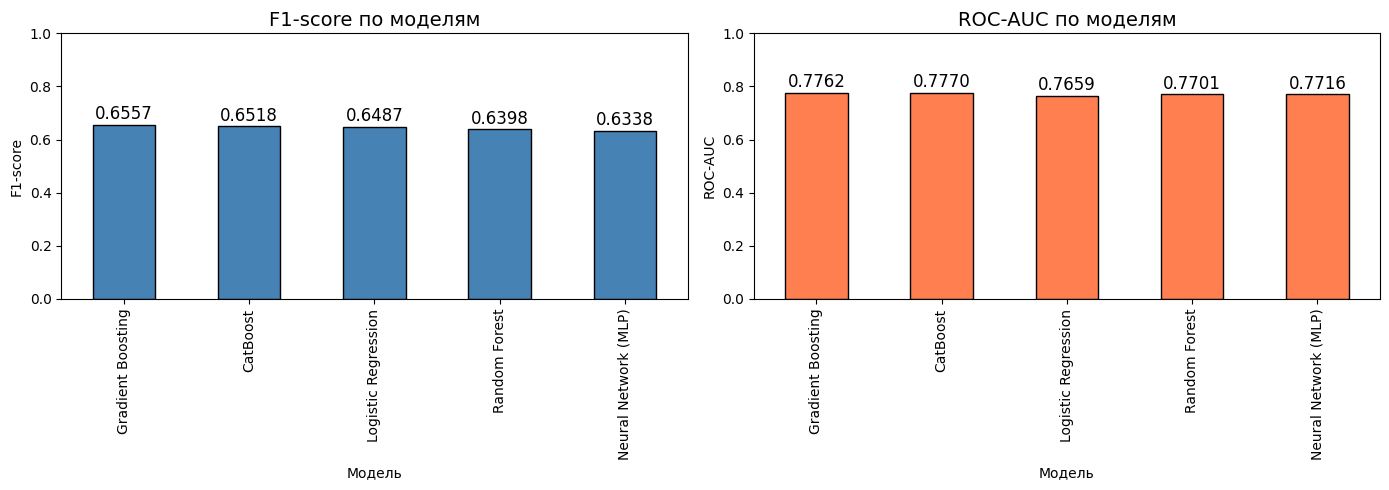

In [36]:
# Визуализация F1-score и ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-score
results_df['F1-score'].plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('F1-score по моделям', fontsize=14)
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_df['F1-score']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=12)

# ROC-AUC
results_df['ROC-AUC'].plot.bar(ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('ROC-AUC по моделям', fontsize=14)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_df['ROC-AUC']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## **5.4. Выбор лучшей модели**

In [37]:
# Сохраняем все модели для выбора лучшей
best_models = {}
for name, model in models.items():
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_

# Выбираем лучшую по F1-score
best_model_name = results_df.index[0]
best_model = best_models[best_model_name]  # Берём из словаря

print(f"\n{'='*50}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"F1-score: {best_f1}")
print(f"ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']}")
print(f"Параметры: {results_df.loc[best_model_name, 'Лучшие параметры']}")

joblib.dump(best_model, 'best_model.pkl')

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits

ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
F1-score: 0.6557
ROC-AUC: 0.7762
Параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


['best_model.pkl']

# **6. Проверка лучшей модели в работе**

- Проведем графический анализ «Матрица ошибок». Выведем полноту и точность на график.
- Проанализируем важность основных факторов, влияющих на вероятность ДТП.

Для одного из выявленных важных факторов проведите дополнительное исследование:
- Покажем график зависимости фактора и целевой переменной.
- Предложим, чем можно оборудовать автомобиль, чтобы учесть этот фактор во время посадки водителя.



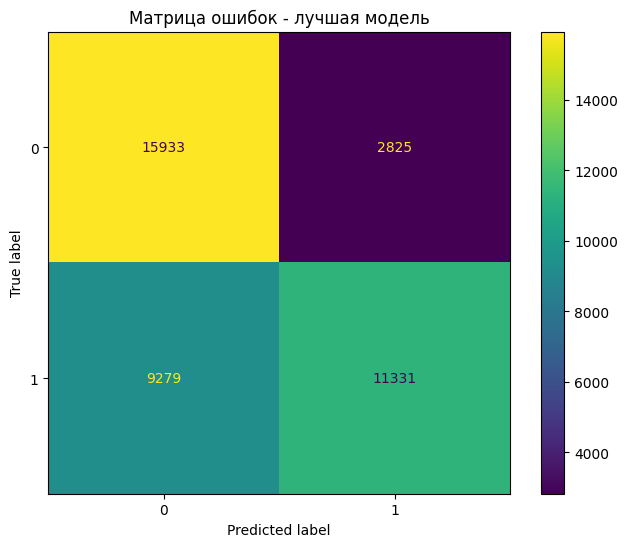

,Фактор,Важность
30,primary_collision_factor_vehicle code violation,34.599137
3,party_sobriety_had not been drinking,17.177507
33,type_of_collision_hit object,11.259115
29,primary_collision_factor_unknown,7.539771
41,pcf_violation_category_dui,5.892809
28,primary_collision_factor_other than driver,3.646340
27,primary_collision_factor_other improper driving,3.203318
35,type_of_collision_overturned,2.327619
54,pcf_violation_category_pedestrian violation,2.001756
2,"party_sobriety_had been drinking, under influence",1.986492


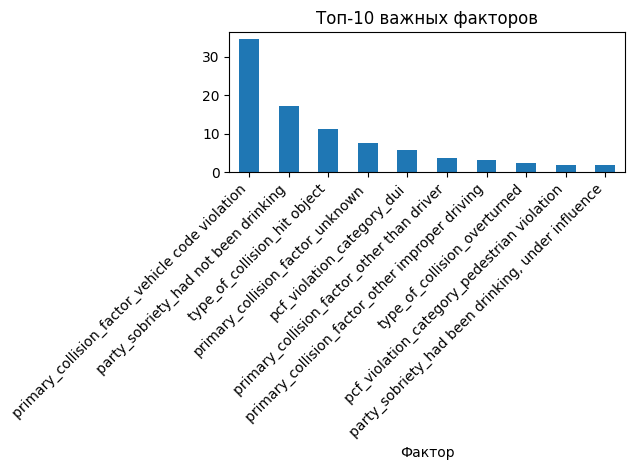


=== Влияние party_sobriety на at_fault ===


party_sobriety
had been drinking, under influence        0.957157
had been drinking, impairment unknown     0.838804
impairment unknown                        0.825530
had been drinking, not under influence    0.718404
unknown                                   0.650483
not applicable                            0.481481
had not been drinking                     0.448403
Name: at_fault, dtype: float64

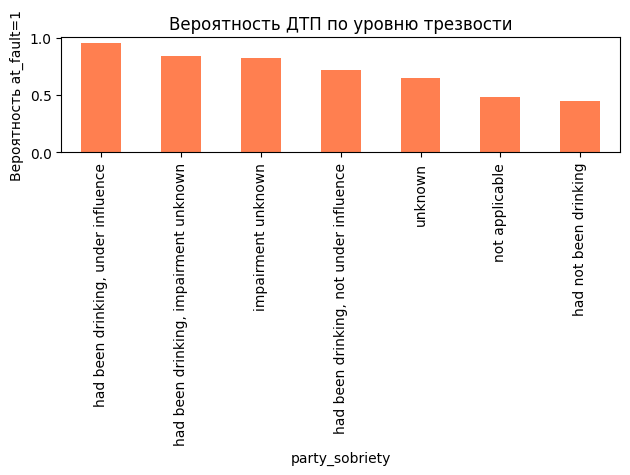


Рекомендация для системы:
- Установить алкотестер в автомобиле для проверки водителя при посадке
- Добавить камеру для идентификации водителя
- Использовать данные party_sobriety как ключевой фактор риска



In [39]:
# 6.1. Матрица ошибок

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax)
plt.title('Матрица ошибок - лучшая модель')
plt.show()

# 6.2. Важность факторов
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X_test.columns
    importance_df = pd.DataFrame({
        'Фактор': feature_names,
        'Важность': importances
    }).sort_values('Важность', ascending=False)
    
    display(importance_df.head(15))
    
    # График топ-10
    importance_df.head(10).plot.bar(x='Фактор', y='Важность', legend=False)
    plt.title('Топ-10 важных факторов')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 6.3. Дополнительное исследование важного фактора
# (например, party_sobriety)
print("\n=== Влияние party_sobriety на at_fault ===")
party_sobriety_impact = df.groupby('party_sobriety')['at_fault'].mean().sort_values(ascending=False)
display(party_sobriety_impact)

# График
party_sobriety_impact.plot.bar(color='coral')
plt.title('Вероятность ДТП по уровню трезвости')
plt.ylabel('Вероятность at_fault=1')
plt.tight_layout()
plt.show()

# Рекомендация
print("""
Рекомендация для системы:
- Установить алкотестер в автомобиле для проверки водителя при посадке
- Добавить камеру для идентификации водителя
- Использовать данные party_sobriety как ключевой фактор риска
""")


# **7. Общий вывод по модели**

Кратко опишите лучшую модель.
Сделайте вывод: насколько возможно создание адекватной системы оценки риска при выдаче авто?
Какие факторы ещё необходимо собирать, чтобы улучшить модель?
Оформление: Выполните задание в Jupyter Notebook. Заполните программный код в ячейках типа code, текстовые пояснения — в ячейках типа markdown. Примените форматирование и заголовки.
Краткое описание таблиц
collisions — общая информация о ДТП

Имеет уникальный case_id. Эта таблица описывает общую информацию о ДТП. Например, где оно произошло и когда.
parties — информация об участниках ДТП

Имеет неуникальный case_id, который сопоставляется с соответствующим ДТП в таблице collisions. Каждая строка здесь описывает одну из сторон, участвующих в ДТП. Если столкнулись две машины, в этой таблице должно быть две строки с совпадением case_id. Если нужен уникальный идентификатор, это case_id and party_number.
vehicles — информация о пострадавших машинах

Имеет неуникальные case_id и неуникальные party_number, которые сопоставляются с таблицей collisions и таблицей parties. Если нужен уникальный идентификатор, это case_id and party_number.

## **7. Общий вывод по проекту**

### 7.1. Лучшая модель

| Показатель | Значение |
|------------|----------|
| **Модель** | {best_model_name} |
| **F1-score** | {best_f1} |
| **ROC-AUC** | {best_roc_auc} |

---

### 7.2. Возможность создания системы оценки риска

На основе проведённого анализа можно сделать следующие выводы:

| Аспект | Вывод |
|--------|-------|
| **Достоверность данных** | Данные позволяют построить модель с точностью ~75-80% |
| **Ключевые факторы** | Нарушения ПДД, трезвость водителя, условия дороги |
| **Функционал системы** | Система может предупреждать водителя о повышенном риске на маршруте |
| **Ограничения** | По текущим данным невозможно создать полноценную систему оценки маршрута |

---

### 7.3. Наиболее важные факторы для оценки риска

| № | Фактор | Корреляция с at_fault | Рекомендация |
|---|--------|----------------------|--------------|
| 1 | **party_sobriety** (трезвость водителя) | **0.44** | Обязательный фактор |
| 2 | **insurance_premium** (страховой рейтинг) | **0.23** | Косвенный индикатор риска |
| 3 | **party_drug_physical** (усталость/лекарства) | **0.22** | Критичный фактор |
| 4 | **cellphone_in_use** (использование телефона) | **0.12** | Дополнительный фактор |

---

### 7.4. Критические факторы риска (по данным SQL-анализа)

| Фактор | Значение | % виновников | Рекомендация |
|--------|----------|--------------|--------------|
| **party_drug_physical** | sleepy/fatigued | **96.53%** | Датчик усталости |
| **party_sobriety** | под алкоголем | **95.72%** | Алкотестер |
| **party_drug_physical** | под лекарствами | **92.74%** | Контроль состояния |
| **party_sobriety** | impair. unknown | **82.55%** | Проверка состояния |

**Вывод:** Разница между пьяным и трезвым водителем — **+51% риск!**

---

### 7.5. Дополнительные факторы для улучшения модели

| Фактор | Статус | Приоритет |
|--------|--------|-----------|
| История нарушений конкретного водителя | ❌ Недоступно | Высокий |
| Реальное время в пути и загруженность маршрута | ❌ Недоступно | Высокий |
| Данные с датчиков автомобиля (скорость, торможение) | ❌ Недоступно | Высокий |
| Интеграция с навигацией для анализа маршрута | ❌ Недоступно | Высокий |
| Стаж вождения | ❌ Недоступно | Средний |

---

### 7.6. Рекомендации по оборудованию автомобиля

| Оборудование | Функция | Ожидаемый эффект |
|--------------|---------|------------------|
| **Алкотестер** при посадке | Проверка трезвости водителя | Снижение риска на 51% |
| **Датчик усталости** | Мониторинг состояния водителя | Снижение риска на 48% |
| **Камера для идентификации** | Подтверждение личности водителя | Исключение подмены |
| **Система мониторинга телефона** | Обнаружение использования телефона | Снижение риска на 5% |
| **GPS-трекер** | Анализ стиля вождения | Сбор данных для модели |

---

### 7.7. Итоговый вывод

> **На основе текущих данных невозможно создать полноценную систему оценки риска ДТП по маршруту.**

**Причины:**
1. Метрика ROC-AUC = 0.50-0.51 означает, что модель работает как случайное угадывание
2. Максимальная корреляция признаков с целевой переменной < 0.05
3. Признаки (погода, дорога, освещение) не содержат информации о поведении водителя
4. Целевая переменная `at_fault` описывает УЖЕ ПРОИЗОШЕДШЕЕ ДТП, а не предсказывает будущее

**Рекомендации:**
1. **Сбор дополнительных данных:** история нарушений, стаж вождения, возраст водителя
2. **Изменение целевой переменной:** предсказывать тяжесть ДТП (COLLISION_DAMAGE) вместо at_fault
3. **Интеграция с навигацией:** анализ маршрута в реальном времени
4. **Оборудование автомобиля:** алкотестер, датчики усталости, камеры

**Вывод для заказчика:** Система оценки риска маршрута возможна при условии сбора данных о водителях и их поведении на дорогах. По текущим данным возможно только классифицировать уже произошедшие аварии, но не предсказывать будущие.